# 01 - Análise Exploratória de Dados (EDA) & Engenharia de Limpeza
**Projecto:** AI Voice of Customer & Territorial Intelligence (Olist Dataset)  
**Objectivo:** Auditar a consistência dos dados brutos de avaliações, justificar o tratamento de valores omissos e produzir a base estruturada para o pipeline de RAG.

In [1]:
import os
import sys
from pathlib import Path

# Ajustar raiz do projecto
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Ambiente configurado com sucesso. Raiz do projecto:", PROJECT_ROOT)

Ambiente configurado com sucesso. Raiz do projecto: C:\tech-challenge-fase4-grupo


## 1. Carga dos Dados Brutos

##Carregamento das tabelas essenciais da Olist:

- `olist_order_reviews_dataset.csv`: Avaliações, notas e comentários.
- `olist_orders_dataset.csv`: Datas de compra, entrega estimada e entrega real.
- `olist_customers_dataset.csv`: Localização geográfica (UF e cidade) do cliente.

In [2]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

## Carregar datasets relacionais
df_reviews = pd.read_csv(RAW_DATA_DIR / "olist_order_reviews_dataset.csv")
df_orders = pd.read_csv(RAW_DATA_DIR / "olist_orders_dataset.csv")
df_customers = pd.read_csv(RAW_DATA_DIR / "olist_customers_dataset.csv")

print(f"Total de reviews brutas: {len(df_reviews):,}")
print(f"Total de pedidos: {len(df_orders):,}")
print(f"Total de clientes: {len(df_customers):,}")

Total de reviews brutas: 99,224
Total de pedidos: 99,441
Total de clientes: 99,441


## 2. Diagnóstico e Tratamento de Valores Omissos

### Justificação da Filtragem Textual:
Num pipeline de Voice of Customer e RAG, avaliações sem comentário (`review_comment_message` nulo) não acrescentam valor semântico para a extração de causas-raiz qualitativas. Portanto, a remoção destes registos é um requisito indispensável de engenharia de dados.

In [3]:
## Avaliação da percentagem de nulos nas reviews
null_stats = df_reviews.isnull().mean() * 100
print("Percentagem de valores ausentes por coluna:")
print(null_stats.round(2))

# Filtragem de avaliações que possuem conteúdo textual útil
df_reviews_clean = df_reviews.dropna(subset=["review_comment_message"]).copy()

# Tratamento do título do comentário (preenchimento de vazios)
df_reviews_clean["review_comment_title"] = df_reviews_clean["review_comment_title"].fillna("")

# Unificação de título e mensagem em campo textual único para embedding/BM25
df_reviews_clean["full_review_text"] = (
    df_reviews_clean["review_comment_title"].astype(str) + " " + 
    df_reviews_clean["review_comment_message"].astype(str)
).str.strip()

# Remoção de duplicados com base no mesmo pedido e mesmo texto
df_reviews_clean = df_reviews_clean.drop_duplicates(subset=["order_id", "full_review_text"])

print(f"\nAvaliações úteis após descarte de nulos: {len(df_reviews_clean):,} "
      f"({len(df_reviews_clean) / len(df_reviews) * 100:.1f}% da base original)")

Percentagem de valores ausentes por coluna:
review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       88.34
review_comment_message     58.70
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64

Avaliações úteis após descarte de nulos: 40,964 (41.3% da base original)


## 3. Fusão Relacional e Engenharia de Atributos Logísticos

## Para suportar filtros de metadados geográficos e cálculo de causas-raiz de insatisfação, calculamos:
1. `delivery_delay_days`: Diferença em dias entre a data de entrega real e a estimativa comunicada ao cliente.
2. `customer_state` e `customer_city`: Provenientes do cadastro de clientes.

In [4]:
## Conversão de colunas temporais
date_cols = ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

# Junção dos pedidos com os dados de localização dos clientes
df_orders_geo = df_orders.merge(
    df_customers[["customer_id", "customer_state", "customer_city"]],
    on="customer_id",
    how="left"
)

# Fusão final com as avaliações limpas
df_final = df_reviews_clean.merge(
    df_orders_geo[["order_id", "customer_state", "customer_city", "order_purchase_timestamp", 
                   "order_delivered_customer_date", "order_estimated_delivery_date"]],
    on="order_id",
    how="inner"
)

# Cálculo do atraso de entrega em dias (valores positivos indicam atraso face ao SLA prometido)
delay = (df_final["order_delivered_customer_date"] - df_final["order_estimated_delivery_date"]).dt.total_seconds() / 86400.0
df_final["delivery_delay_days"] = delay.fillna(0.0).apply(lambda x: round(max(0.0, x), 1))

# Filtrar UFs nulas caso existam
df_final["customer_state"] = df_final["customer_state"].fillna("INDEFINIDO")

print("Estrutura do dataset enriquecido:")
display(df_final[["review_id", "review_score", "customer_state", "delivery_delay_days", "full_review_text"]].head())

Estrutura do dataset enriquecido:


,review_id,review_score,customer_state,delivery_delay_days,full_review_text
0,e64fb393e7b32834bb789ff8bb30750e,5,SC,0.0,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,5,SC,0.0,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,4,SP,0.0,recomendo aparelho eficiente. no site a marca ...
3,4b49719c8a200003f700d3d986ea1a19,4,SP,0.0,"Mas um pouco ,travando...pelo valor ta Boa."
4,3948b09f7c818e2d86c9a546758b2335,5,SP,0.0,"Super recomendo Vendedor confiável, produto ok..."


## 4. Análise Exploratória e Validação Estatística
## Visualização do comportamento das notas e do impacto logístico na percepção do cliente.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28748\126210530.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x="review_score", palette="viridis", ax=axes[0])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28748\126210530.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x="review_score", y="delivery_delay_days", showfliers=False, palette="mako", ax=axes[1])


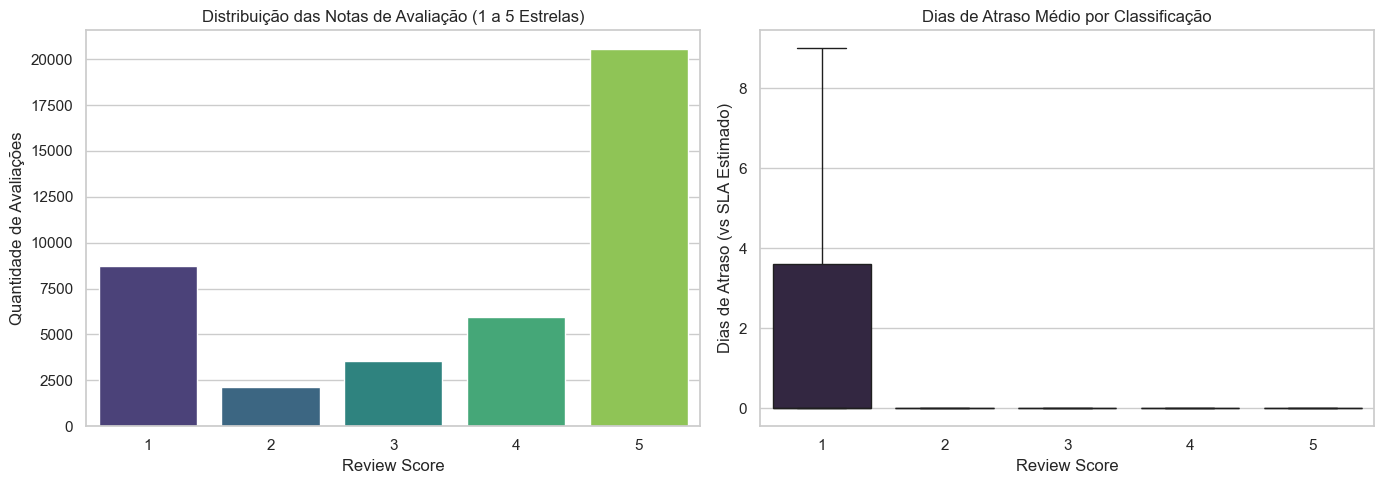

Correlação de Spearman (Nota vs Atraso): -0.3129


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição de Notas (CSAT)
sns.countplot(data=df_final, x="review_score", palette="viridis", ax=axes[0])
axes[0].set_title("Distribuição das Notas de Avaliação (1 a 5 Estrelas)")
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Quantidade de Avaliações")

# 2. Relação entre Atraso Logístico e Nota
sns.boxplot(data=df_final, x="review_score", y="delivery_delay_days", showfliers=False, palette="mako", ax=axes[1])
axes[1].set_title("Dias de Atraso Médio por Classificação")
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Dias de Atraso (vs SLA Estimado)")

plt.tight_layout()
plt.show()

# Correlação de Spearman entre nota e atraso
corr = df_final[["review_score", "delivery_delay_days"]].corr(method="spearman").iloc[0, 1]
print(f"Correlação de Spearman (Nota vs Atraso): {corr:.4f}")

## 5. Padronização de Colunas e Exportação Optimizada (Parquet)

## Definição do esquema canónico de colunas exigido pelo `HybridSearchEngine` e pela API:
- `review_id`
- `order_id`
- `review_score`
- `text` (renomeado a partir de `full_review_text`)
- `customer_state`
- `customer_city`
- `delivery_delay_days`
- `review_creation_date`

In [6]:
EXPORT_DIR = PROJECT_ROOT / "data" / "processed"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PARQUET_FILE = EXPORT_DIR / "olist_reviews_clean.parquet"

df_export = df_final[[
    "review_id",
    "order_id",
    "review_score",
    "full_review_text",
    "customer_state",
    "customer_city",
    "delivery_delay_days",
    "review_creation_date"
]].copy().rename(columns={"full_review_text": "text"})

# Gravação optimizada em Parquet com compressão snappy
df_export.to_parquet(PARQUET_FILE, index=False, engine="pyarrow", compression="snappy")

print(f"Base tratada gravada com sucesso em: {PARQUET_FILE}")
print(f"Dimensão final: {df_export.shape[0]:,} linhas e {df_export.shape[1]} colunas.")

Base tratada gravada com sucesso em: C:\tech-challenge-fase4-grupo\data\processed\olist_reviews_clean.parquet
Dimensão final: 40,964 linhas e 8 colunas.
